<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/KNN_Complete_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Nearest Neighbors (KNN)**
### **Course:** AIML with IIT Ropar
### **Faculty:** Lovnish Verma, Project Engineer

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/0*Ret1zR8FuYOJHWEh.png" hieght="128" width="512">

---

> **"Tell me who your neighbors are, and I'll tell you who you are."**

---

## Table of Contents
1. Setup and Imports
2. Intuition - What is KNN?
3. Manual KNN - Step-by-Step (Classroom Activity)
4. Distance Metrics Explained
5. The Role of K - Overfitting vs Underfitting
6. KNN on Iris Dataset with EDA
7. Feature Scaling - Why It Critically Matters
8. Choosing Optimal K with Cross-Validation
9. KNN on Wine Dataset - Real World Pipeline
10. Decision Boundary Visualization (2D)
11. KNN for Regression
12. GridSearchCV - Best K and Best Distance Metric
13. Predict New Data Points - Production Pattern
14. Prediction Time vs Dataset Size (Complexity)
15. KNN vs Decision Tree vs Random Forest
16. Assignment Tasks
17. Summary and Key Takeaways

---
## 1. Setup and Imports

In [ ]:
# CELL 1: All Imports - Run This First

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import time
import warnings
warnings.filterwarnings('ignore')

# Datasets
from sklearn.datasets import load_iris, load_wine, make_classification, make_moons

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Models
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    r2_score
)

print('All libraries imported successfully.')
print('Environment is ready')

All libraries imported successfully.
Environment is ready


---
## 2. Intuition - What is KNN?

### Core Idea (one-liner)
> KNN classifies a data point based on the **majority class of its K nearest neighbors**.

### Why is it called a Lazy Learner?
- KNN does **no computation during training**
- It simply **memorizes** all training data
- All computation happens at **prediction time**

### Algorithm Steps
1. Choose K (number of neighbors)
2. Compute distance from new point to every training point
3. Select the K closest points
4. Take majority vote (classification) or average (regression)
5. Return the prediction

### Real-World Analogy
- You move to a new city and want to know your profession group
- You look at your 5 nearest neighbors
- 4 are engineers, 1 is a doctor
- Prediction: you are likely an engineer

---
## 3. Manual KNN - Classroom Activity

In [ ]:
# CELL 2: Manual KNN — Step-by-Step
# Students should trace this logic by hand first

# Training points
training_points = {
    'Point':  ['P1', 'P2', 'P3', 'P4', 'P5', 'P6'],
    'X':      [1,    2,    2,    6,    7,    7],
    'Y':      [1,    2,    3,    6,    7,    6],
    'Class':  ['A',  'A',  'A',  'B',  'B',  'B']
}
df_train = pd.DataFrame(training_points)

print('Training Data:')
print(df_train.to_string(index=False))

# New point to classify
new_point = np.array([3, 3])
K = 3
print(f'\nNew Point: {new_point}  |  K = {K}')

# STEP 1: Compute Euclidean distances
print('\n--- STEP 1: Compute Euclidean Distances ---')
distances = []
for _, row in df_train.iterrows():
    pt = np.array([row['X'], row['Y']])
    dist = np.sqrt((new_point[0]-pt[0])**2 + (new_point[1]-pt[1])**2)
    distances.append(round(dist, 3))
    print(f'  {row["Point"]} ({row["X"]},{row["Y"]}) [{row["Class"]}]  ->  d = {dist:.3f}')

df_train['Distance'] = distances

# STEP 2: Sort by distance
df_sorted = df_train.sort_values('Distance').reset_index(drop=True)
print('\n--- STEP 2: Sorted by Distance ---')
print(df_sorted.to_string(index=False))

# STEP 3: Select K nearest
k_nearest = df_sorted.head(K)
print(f'\n--- STEP 3: {K} Nearest Neighbors ---')
print(k_nearest[['Point','X','Y','Class','Distance']].to_string(index=False))

# STEP 4: Majority vote
vote = k_nearest['Class'].value_counts()
prediction = vote.idxmax()
print(f'\n--- STEP 4: Majority Vote ---')
print(vote.to_string())
print(f'\nPredicted Class for {new_point}: "{prediction}"')

Training Data:
Point  X  Y Class
   P1  1  1     A
   P2  2  2     A
   P3  2  3     A
   P4  6  6     B
   P5  7  7     B
   P6  7  6     B

New Point: [3 3]  |  K = 3

--- STEP 1: Compute Euclidean Distances ---
  P1 (1,1) [A]  ->  d = 2.828
  P2 (2,2) [A]  ->  d = 1.414
  P3 (2,3) [A]  ->  d = 1.000
  P4 (6,6) [B]  ->  d = 4.243
  P5 (7,7) [B]  ->  d = 5.657
  P6 (7,6) [B]  ->  d = 5.000

--- STEP 2: Sorted by Distance ---
Point  X  Y Class  Distance
   P3  2  3     A     1.000
   P2  2  2     A     1.414
   P1  1  1     A     2.828
   P4  6  6     B     4.243
   P6  7  6     B     5.000
   P5  7  7     B     5.657

--- STEP 3: 3 Nearest Neighbors ---
Point  X  Y Class  Distance
   P3  2  3     A     1.000
   P2  2  2     A     1.414
   P1  1  1     A     2.828

--- STEP 4: Majority Vote ---
Class
A    3

Predicted Class for [3 3]: "A"


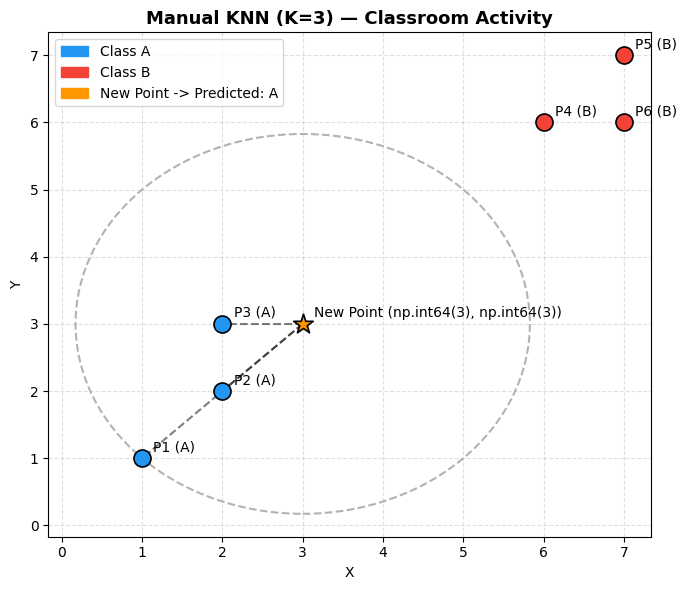

Conclusion: New point (np.int64(3), np.int64(3)) is classified as Class "A"


In [ ]:
# CELL 3: Visualize Manual KNN

fig, ax = plt.subplots(figsize=(7, 6))
colors = {'A': '#2196F3', 'B': '#F44336'}

for _, row in df_train.iterrows():
    ax.scatter(row['X'], row['Y'], color=colors[row['Class']],
               s=150, zorder=5, edgecolors='black', linewidth=1.2)
    ax.annotate(f"{row['Point']} ({row['Class']})",
                (row['X'], row['Y']), textcoords='offset points',
                xytext=(8, 5), fontsize=10)

# New point
ax.scatter(*new_point, color='#FF9800', s=220, marker='*',
           zorder=6, edgecolors='black', linewidth=1.2)
ax.annotate(f'New Point {tuple(new_point)}',
            new_point, textcoords='offset points', xytext=(8, 5), fontsize=10)

# Lines to K neighbors
for _, row in k_nearest.iterrows():
    ax.plot([new_point[0], row['X']], [new_point[1], row['Y']],
            'k--', alpha=0.5, linewidth=1.5)

# K-radius circle
k_radius = k_nearest['Distance'].max()
circle = plt.Circle(new_point, k_radius, fill=False,
                    color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax.add_patch(circle)

patch_A = mpatches.Patch(color='#2196F3', label='Class A')
patch_B = mpatches.Patch(color='#F44336', label='Class B')
patch_N = mpatches.Patch(color='#FF9800', label=f'New Point -> Predicted: {prediction}')
ax.legend(handles=[patch_A, patch_B, patch_N], fontsize=10)

ax.set_title(f'Manual KNN (K={K}) — Classroom Activity', fontsize=13, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Conclusion: New point {tuple(new_point)} is classified as Class "{prediction}"')

---
## 4. Distance Metrics

KNN is 100% dependent on the distance function used.

| Metric | Formula | Use Case |
|---|---|---|
| Euclidean | sqrt(sum of squared diffs) | Continuous features, low dimensions |
| Manhattan | sum of absolute diffs | Grid-like, robust to outliers |
| Minkowski | Generalized (p=1 -> Manhattan, p=2 -> Euclidean) | Flexible |

### Euclidean Distance
$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

Points: A = [1 2]  |  B = [4 6]
Euclidean Distance   : 5.0000
  sqrt((4-1)^2 + (6-2)^2)

Manhattan Distance   : 7
  |4-1| + |6-2|

Minkowski (p=3)    : 4.4979


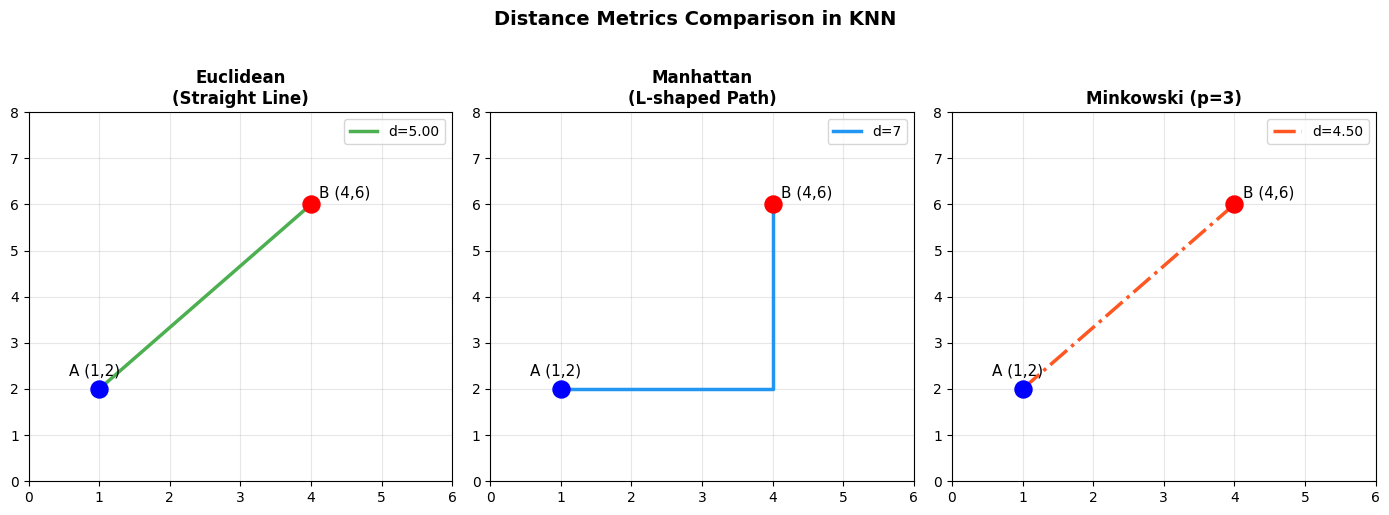

In [ ]:
# CELL 4: Distance Metrics - Computation + Visual

point_a = np.array([1, 2])
point_b = np.array([4, 6])

# Compute distances
euclid   = np.sqrt(np.sum((point_a - point_b)**2))
manhattan = np.sum(np.abs(point_a - point_b))
p = 3
mink = np.sum(np.abs(point_a - point_b)**p)**(1/p)

print(f'Points: A = {point_a}  |  B = {point_b}')
print('='*45)
print(f'Euclidean Distance   : {euclid:.4f}')
print(f'  sqrt(({point_b[0]}-{point_a[0]})^2 + ({point_b[1]}-{point_a[1]})^2)')
print(f'\nManhattan Distance   : {manhattan}')
print(f'  |{point_b[0]}-{point_a[0]}| + |{point_b[1]}-{point_a[1]}|')
print(f'\nMinkowski (p={p})    : {mink:.4f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
titles = ['Euclidean\n(Straight Line)', 'Manhattan\n(L-shaped Path)', f'Minkowski (p={p})']
dist_colors = ['#4CAF50', '#2196F3', '#FF5722']
dist_labels = [f'd={euclid:.2f}', f'd={manhattan}', f'd={mink:.2f}']

for idx, ax in enumerate(axes):
    ax.scatter(*point_a, color='blue', s=150, zorder=5)
    ax.scatter(*point_b, color='red',  s=150, zorder=5)
    ax.annotate('A (1,2)', point_a, xytext=(-22, 10), textcoords='offset points', fontsize=11)
    ax.annotate('B (4,6)', point_b, xytext=(6, 5),  textcoords='offset points', fontsize=11)

    if idx == 0:
        ax.plot([point_a[0], point_b[0]], [point_a[1], point_b[1]],
                color=dist_colors[idx], linewidth=2.5, label=dist_labels[idx])
    elif idx == 1:
        ax.plot([point_a[0], point_b[0], point_b[0]],
                [point_a[1], point_a[1], point_b[1]],
                color=dist_colors[idx], linewidth=2.5, label=dist_labels[idx])
    else:
        ax.plot([point_a[0], point_b[0]], [point_a[1], point_b[1]],
                color=dist_colors[idx], linewidth=2.5, linestyle='-.', label=dist_labels[idx])

    ax.set_title(titles[idx], fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 8)

plt.suptitle('Distance Metrics Comparison in KNN', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. The Role of K - Overfitting vs Underfitting

| K Value | Behavior | Reason |
|---|---|---|
| K = 1 | Overfitting | Memorizes every point including noise |
| K = 3 to 7 | Typically good | Balances bias and variance |
| K very large | Underfitting | Too many voters, smooths everything |

> **Golden Rule: Never guess K. Use cross-validation.**

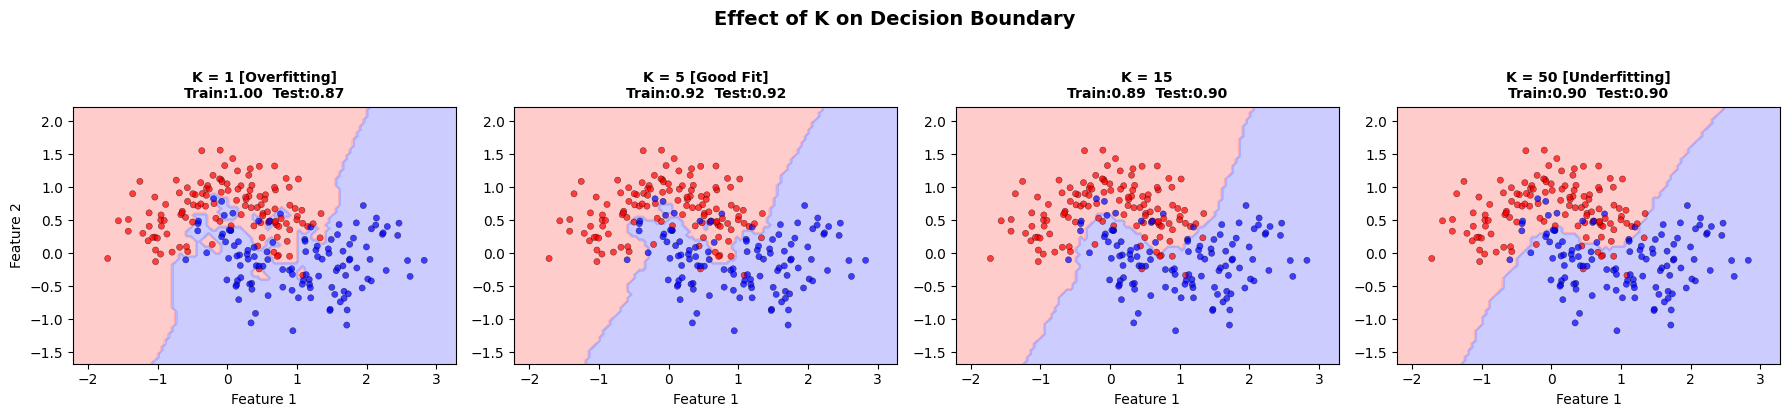

K=1  -> Captures every noisy point    -> OVERFITTING
K=5  -> Balanced boundary             -> GOOD FIT
K=15 -> Smoother
K=50 -> Over-smoothed                 -> UNDERFITTING


In [ ]:
# CELL 5: Effect of K — Decision Boundary Comparison

X_syn, y_syn = make_moons(n_samples=300, noise=0.3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

k_values = [1, 5, 15, 50]
h = 0.05
x_min, x_max = X_syn[:, 0].min()-0.5, X_syn[:, 0].max()+0.5
y_min, y_max = X_syn[:, 1].min()-0.5, X_syn[:, 1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, k in zip(axes, k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    train_acc = model.score(X_tr, y_tr)
    test_acc  = model.score(X_te, y_te)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_bold,
               s=20, edgecolors='k', linewidth=0.3, alpha=0.7)

    label = ''
    if k == 1:  label = ' [Overfitting]'
    elif k == 5: label = ' [Good Fit]'
    elif k == 50: label = ' [Underfitting]'

    ax.set_title(f'K = {k}{label}\nTrain:{train_acc:.2f}  Test:{test_acc:.2f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2' if k == 1 else '')

plt.suptitle('Effect of K on Decision Boundary', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('K=1  -> Captures every noisy point    -> OVERFITTING')
print('K=5  -> Balanced boundary             -> GOOD FIT')
print('K=15 -> Smoother')
print('K=50 -> Over-smoothed                 -> UNDERFITTING')

---
## 6. KNN on Iris Dataset with EDA

In [ ]:
# CELL 6: Iris — Load and Explore

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names  = iris.target_names
feature_names = iris.feature_names

df_iris = pd.DataFrame(X_iris, columns=feature_names)
df_iris['Species'] = [target_names[i] for i in y_iris]

print('Dataset Shape:', X_iris.shape)
print('Classes:', target_names)
print('\nFirst 5 rows:')
print(df_iris.head().to_string(index=False))
print('\nClass Distribution:')
print(df_iris['Species'].value_counts().to_string())
print('\nStatistics:')
print(df_iris.describe().round(2).to_string())

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) Species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

Class Distribution:
Species
setosa        50
versicolor    50
virginica     50

Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean                5.84              3.06               3.76              1.20
std                 0.83              0.44               1.77              0.76
min        

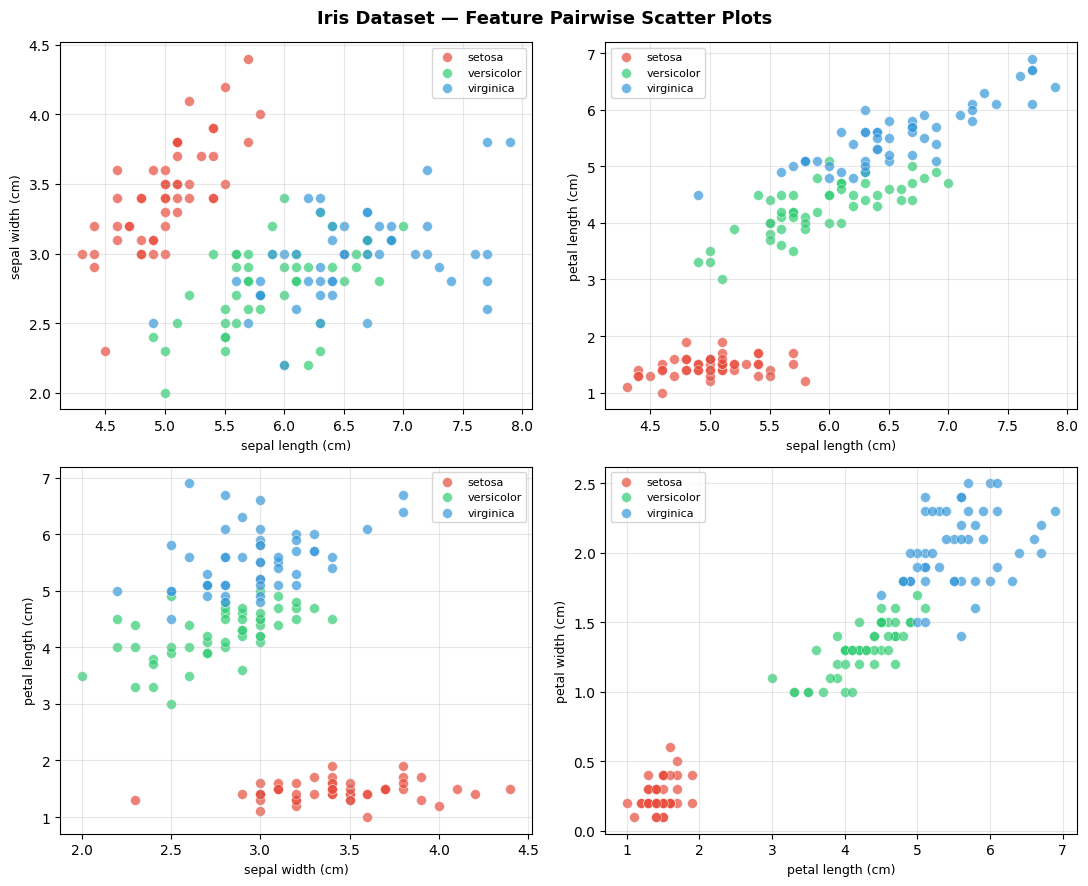

In [ ]:
# CELL 7: Iris - EDA Scatter Plots

colors_iris = ['#E74C3C', '#2ECC71', '#3498DB']
pairs = [(0, 1), (0, 2), (1, 2), (2, 3)]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (i, j) in zip(axes.ravel(), pairs):
    for cls_idx, cls in enumerate(target_names):
        mask = y_iris == cls_idx
        ax.scatter(X_iris[mask, i], X_iris[mask, j],
                   color=colors_iris[cls_idx], label=cls,
                   s=50, alpha=0.7, edgecolors='white', linewidth=0.4)
    ax.set_xlabel(feature_names[i], fontsize=9)
    ax.set_ylabel(feature_names[j], fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Iris Dataset — Feature Pairwise Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

KNN (K=5) on Iris — WITHOUT Scaling
Test Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



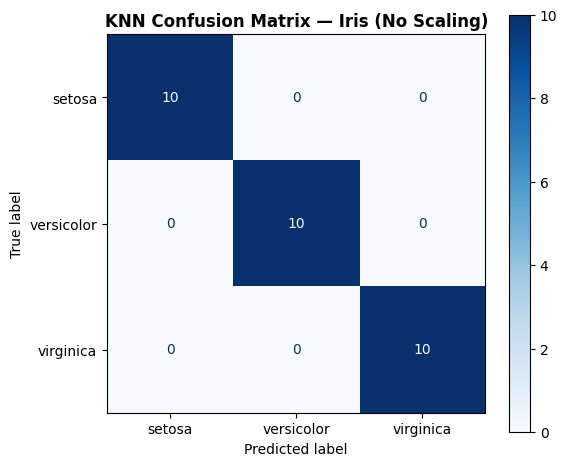

In [ ]:
# CELL 8: Iris - Train KNN (Without Scaling)

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('KNN (K=5) on Iris — WITHOUT Scaling')
print('='*40)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Iris (No Scaling)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Feature Scaling - Why It Critically Matters

### The Problem
- Feature A: range [0.0 — 1.0]
- Feature B: range [0 — 100000]

Without scaling, **Feature B completely dominates** the distance calculation. Feature A becomes irrelevant.

### The Solution: StandardScaler
Transforms each feature so that **mean = 0** and **std = 1**.

```python
# CORRECT pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)        # transform only on test data
```

In [ ]:
# CELL 9: Feature Scaling - Impact Demonstration

# Without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
acc_no_scale = knn_no_scale.score(X_test, y_test)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Only transform — never refit on test!

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = knn_scaled.score(X_test_scaled, y_test)

print('Feature Scaling Impact (K=5, Iris)')
print('-'*40)
print(f'Without Scaling : {acc_no_scale:.4f} ({acc_no_scale*100:.2f}%)')
print(f'With Scaling    : {acc_scaled:.4f}  ({acc_scaled*100:.2f}%)')
print(f'Improvement     : +{(acc_scaled - acc_no_scale)*100:.2f}%')

print('\nFeature Ranges BEFORE Scaling:')
for i, feat in enumerate(feature_names):
    print(f'  {feat:32s}: [{X_train[:, i].min():.2f}, {X_train[:, i].max():.2f}]')

print('\nFeature Ranges AFTER Scaling (mean=0, std=1):')
for i, feat in enumerate(feature_names):
    print(f'  {feat:32s}: [{X_train_scaled[:, i].min():.2f}, {X_train_scaled[:, i].max():.2f}]')

Feature Scaling Impact (K=5, Iris)
----------------------------------------
Without Scaling : 1.0000 (100.00%)
With Scaling    : 0.9333  (93.33%)
Improvement     : +-6.67%

Feature Ranges BEFORE Scaling:
  sepal length (cm)               : [4.30, 7.90]
  sepal width (cm)                : [2.00, 4.40]
  petal length (cm)               : [1.10, 6.90]
  petal width (cm)                : [0.10, 2.50]

Feature Ranges AFTER Scaling (mean=0, std=1):
  sepal length (cm)               : [-1.84, 2.46]
  sepal width (cm)                : [-2.35, 3.03]
  petal length (cm)               : [-1.52, 1.78]
  petal width (cm)                : [-1.45, 1.71]


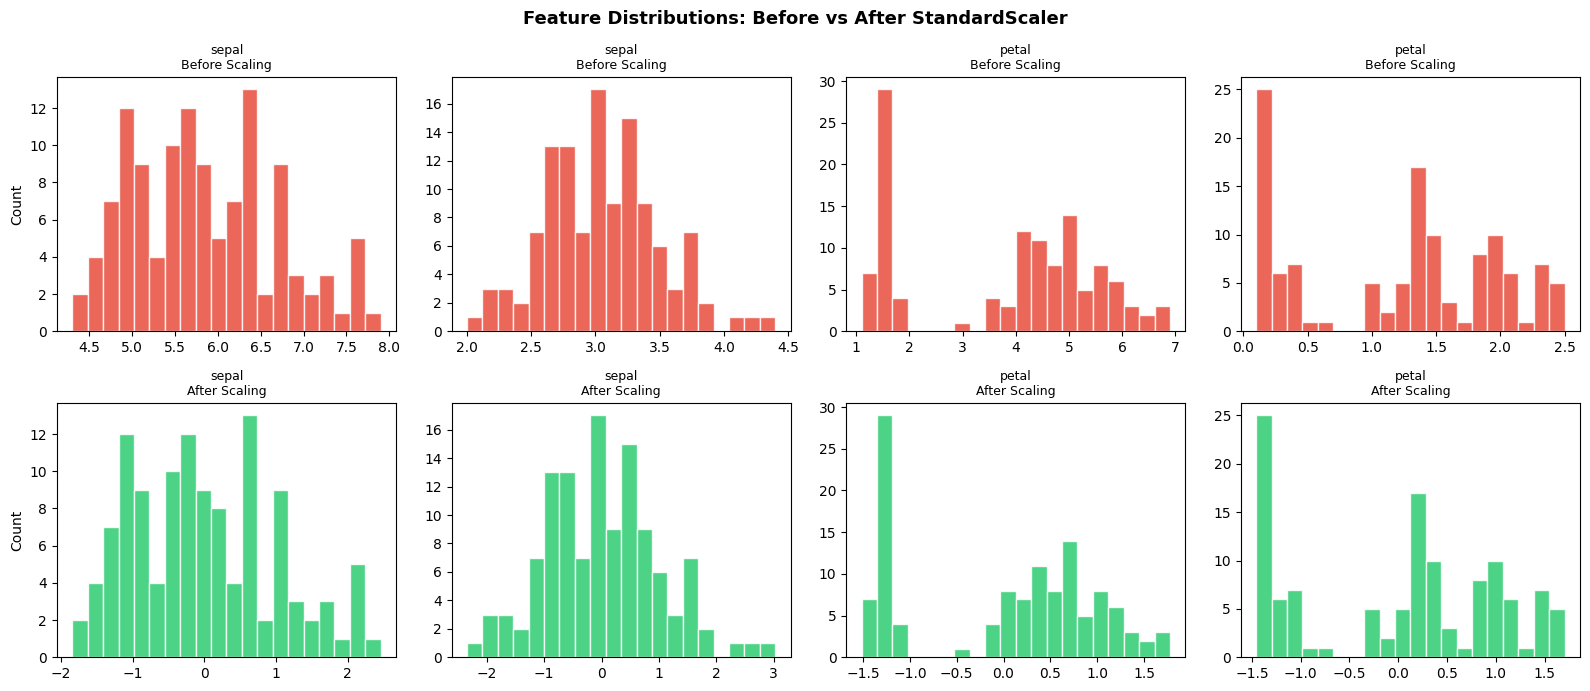

In [ ]:
# CELL 10: Distribution Before vs After Scaling


fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, feat in enumerate(feature_names):
    axes[0, i].hist(X_train[:, i], bins=20, color='#E74C3C', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{feat.split(" ")[0]}\nBefore Scaling', fontsize=9)
    axes[0, i].set_ylabel('Count' if i == 0 else '')

    axes[1, i].hist(X_train_scaled[:, i], bins=20, color='#2ECC71', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{feat.split(" ")[0]}\nAfter Scaling', fontsize=9)
    axes[1, i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('Feature Distributions: Before vs After StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Choosing Optimal K with Cross-Validation

Best K        : 5
Best CV Score : 0.9667 (96.67%)


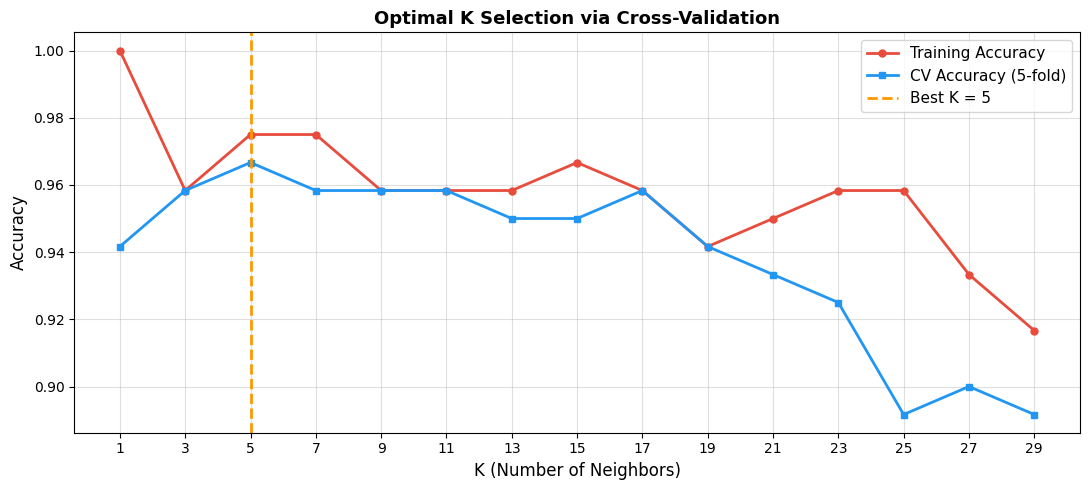

Insight: Where Training Accuracy >> CV Accuracy -> Overfitting zone


In [ ]:
# CELL 11: Find Optimal K Using Cross-Validation

k_range = range(1, 31, 2) #start, Stop, Jump (step)
train_scores = []
cv_scores    = []

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k)
    cv = cross_val_score(m, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())
    m.fit(X_train_scaled, y_train)
    train_scores.append(m.score(X_train_scaled, y_train))

best_k  = list(k_range)[np.argmax(cv_scores)]
best_cv = max(cv_scores)

print(f'Best K        : {best_k}')
print(f'Best CV Score : {best_cv:.4f} ({best_cv*100:.2f}%)')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_range, train_scores, 'o-', color='#E74C3C', linewidth=2, markersize=5, label='Training Accuracy')
ax.plot(k_range, cv_scores,    's-', color='#2196F3', linewidth=2, markersize=5, label='CV Accuracy (5-fold)')
ax.axvline(x=best_k, color='#FF9800', linestyle='--', linewidth=2, label=f'Best K = {best_k}')

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Optimal K Selection via Cross-Validation', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Insight: Where Training Accuracy >> CV Accuracy -> Overfitting zone')

---
## 9. KNN on Wine Dataset - Real World Pipeline

In [ ]:
# CELL 12: Wine Dataset — Load and Explore

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
wine_features = wine.feature_names
wine_classes  = wine.target_names

print('Wine Dataset')
print('-'*30)
print(f'Samples  : {X_wine.shape[0]}')
print(f'Features : {X_wine.shape[1]}')
print(f'Classes  : {wine_classes}')

df_wine = pd.DataFrame(X_wine, columns=wine_features)
print('\nFeature Ranges (notice huge differences -> scaling is mandatory!):')
print(df_wine.describe().loc[['min','max','mean']].round(2).T.to_string())

Wine Dataset
------------------------------
Samples  : 178
Features : 13
Classes  : ['class_0' 'class_1' 'class_2']

Feature Ranges (notice huge differences -> scaling is mandatory!):
                                 min      max    mean
alcohol                        11.03    14.83   13.00
malic_acid                      0.74     5.80    2.34
ash                             1.36     3.23    2.37
alcalinity_of_ash              10.60    30.00   19.49
magnesium                      70.00   162.00   99.74
total_phenols                   0.98     3.88    2.30
flavanoids                      0.34     5.08    2.03
nonflavanoid_phenols            0.13     0.66    0.36
proanthocyanins                 0.41     3.58    1.59
color_intensity                 1.28    13.00    5.06
hue                             0.48     1.71    0.96
od280/od315_of_diluted_wines    1.27     4.00    2.61
proline                       278.00  1680.00  746.89


In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
# CELL 13: Wine - Full Pipeline with Best K

X_trw, X_tew, y_trw, y_tew = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

# Without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_trw, y_trw)
acc_raw = knn_raw.score(X_tew, y_tew)

# With scaling
sc_wine = StandardScaler()
X_trws  = sc_wine.fit_transform(X_trw)
X_tews  = sc_wine.transform(X_tew)

# Find best K via cross-validation
best_k_wine, best_acc_wine = 1, 0
for k in range(1, 21, 2):
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_trws, y_trw, cv=5).mean()
    if s > best_acc_wine:
        best_acc_wine = s
        best_k_wine   = k

knn_best_wine = KNeighborsClassifier(n_neighbors=best_k_wine)
knn_best_wine.fit(X_trws, y_trw)
acc_best_wine = knn_best_wine.score(X_tews, y_tew)

print('Wine Dataset Results')
print('-'*45)
print(f'KNN K=5  (no scaling)       : {acc_raw:.4f} ({acc_raw*100:.2f}%)')
print(f'KNN K={best_k_wine} (with scaling)   : {acc_best_wine:.4f} ({acc_best_wine*100:.2f}%)')
print(f'Improvement                 : +{(acc_best_wine-acc_raw)*100:.2f}%')
print()
print('Classification Report (Best Model):')
print(classification_report(y_tew, knn_best_wine.predict(X_tews), target_names=wine_classes))

Wine Dataset Results
---------------------------------------------
KNN K=5  (no scaling)       : 0.7778 (77.78%)
KNN K=11 (with scaling)   : 0.9778 (97.78%)
Improvement                 : +20.00%

Classification Report (Best Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



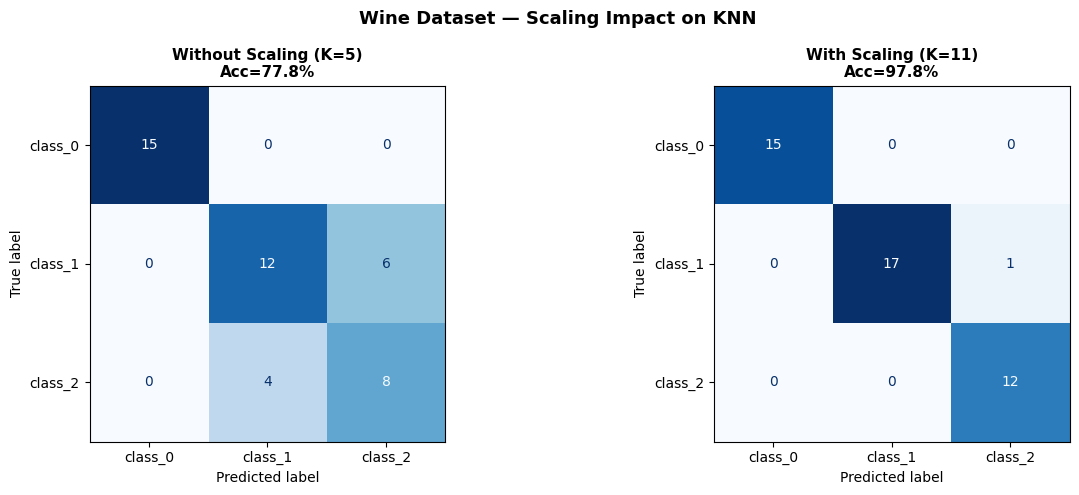

In [ ]:
# CELL 14: Wine — Confusion Matrix Comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs = [
    (knn_raw,       X_tew,  f'Without Scaling (K=5)\nAcc={acc_raw*100:.1f}%'),
    (knn_best_wine, X_tews, f'With Scaling (K={best_k_wine})\nAcc={acc_best_wine*100:.1f}%')
]

for ax, (model, X_te_i, title) in zip(axes, configs):
    cm = confusion_matrix(y_tew, model.predict(X_te_i))
    ConfusionMatrixDisplay(cm, display_labels=wine_classes).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Wine Dataset — Scaling Impact on KNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Decision Boundary Visualization (2D)

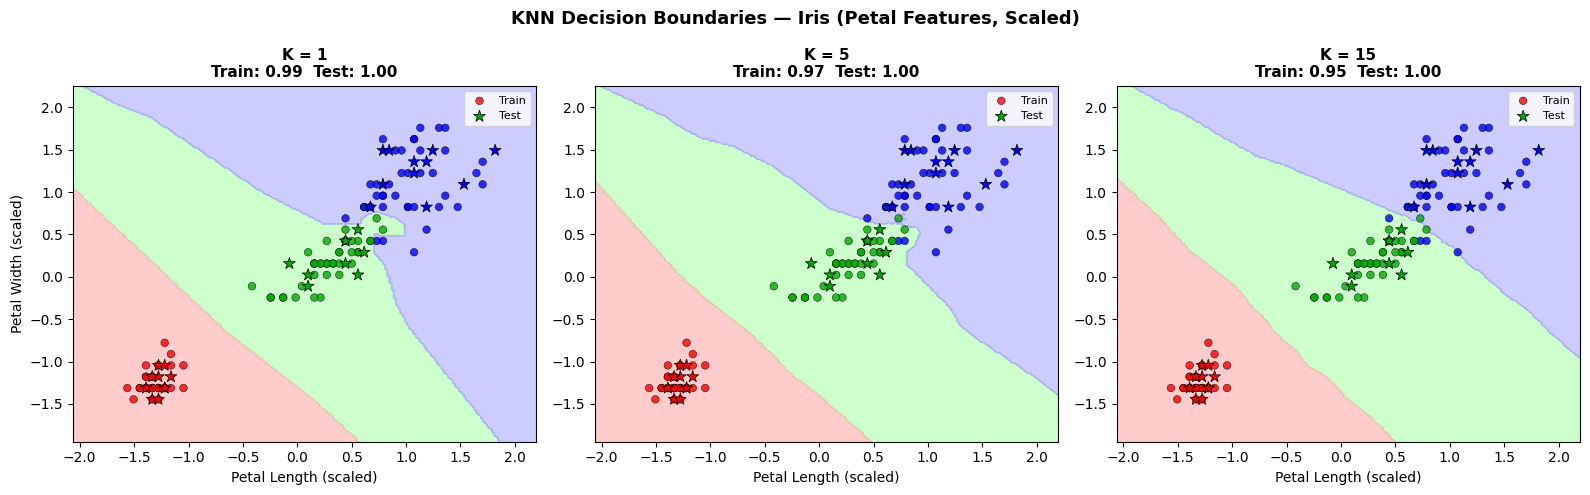

In [ ]:
# CELL 15: Decision Boundary - 2 Features from Iris

X_2d = X_iris[:, 2:4]   # petal length, petal width
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_2d, y_iris, test_size=0.2, random_state=42)
sc2 = StandardScaler()
X_tr2s = sc2.fit_transform(X_tr2)
X_te2s  = sc2.transform(X_te2)

h = 0.02
x0_min, x0_max = X_tr2s[:, 0].min()-0.5, X_tr2s[:, 0].max()+0.5
x1_min, x1_max = X_tr2s[:, 1].min()-0.5, X_tr2s[:, 1].max()+0.5
xx2, yy2 = np.meshgrid(np.arange(x0_min, x0_max, h), np.arange(x1_min, x1_max, h))

cmap_light3 = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold3  = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [1, 5, 15]):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_tr2s, y_tr2)
    Z = m.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)

    ax.contourf(xx2, yy2, Z, cmap=cmap_light3, alpha=0.6)
    ax.scatter(X_tr2s[:, 0], X_tr2s[:, 1], c=y_tr2, cmap=cmap_bold3,
               s=30, edgecolors='k', linewidth=0.4, alpha=0.8, label='Train')
    ax.scatter(X_te2s[:, 0], X_te2s[:, 1], c=y_te2, cmap=cmap_bold3,
               s=80, marker='*', edgecolors='k', linewidth=0.5, label='Test')

    ta = m.score(X_tr2s, y_tr2)
    va = m.score(X_te2s, y_te2)
    ax.set_title(f'K = {k}\nTrain: {ta:.2f}  Test: {va:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Petal Length (scaled)')
    ax.set_ylabel('Petal Width (scaled)' if k == 1 else '')
    ax.legend(fontsize=8)

plt.suptitle('KNN Decision Boundaries — Iris (Petal Features, Scaled)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. KNN for Regression

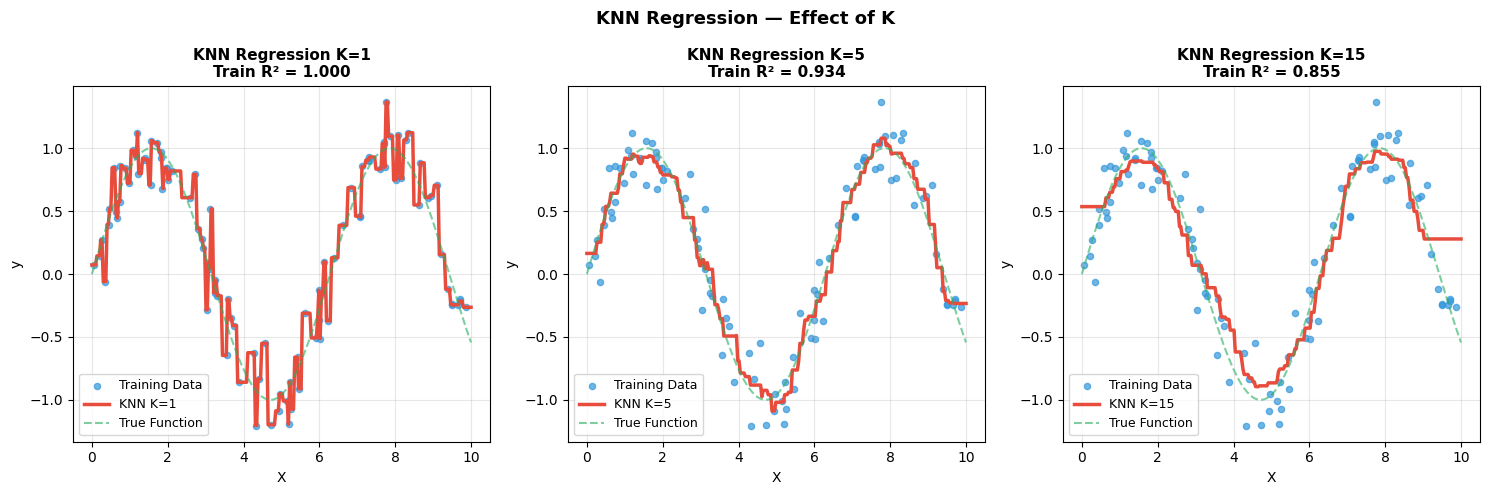

In regression, KNN predicts the AVERAGE value of K nearest neighbors.
K=1 -> Jagged, overfits   |   Large K -> Smooth, underfits


In [ ]:
# CELL 16: KNN Regression — 1D Sine Wave
# KNN predicts the AVERAGE of K nearest neighbors' values

np.random.seed(42)
X_reg = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, 100)
X_line = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, [1, 5, 15]):
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(X_reg, y_reg)
    y_line = knn_r.predict(X_line)
    r2 = r2_score(y_reg, knn_r.predict(X_reg))

    ax.scatter(X_reg, y_reg, color='#3498DB', s=20, alpha=0.7, label='Training Data')
    ax.plot(X_line, y_line, color='#E74C3C', linewidth=2.5, label=f'KNN K={k}')
    ax.plot(X_line, np.sin(X_line), '--', color='#27AE60', linewidth=1.5, alpha=0.6, label='True Function')

    ax.set_title(f'KNN Regression K={k}\nTrain R\u00b2 = {r2:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('KNN Regression — Effect of K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('In regression, KNN predicts the AVERAGE value of K nearest neighbors.')
print('K=1 -> Jagged, overfits   |   Large K -> Smooth, underfits')

---
## 12. GridSearchCV - Best K + Best Distance Metric

In [ ]:
kk = []
for r in range(3, 16, 2):
    kk.append(r)


kk


[3, 5, 7, 9, 11, 13, 15]

In [ ]:
# CELL 17: GridSearchCV — Full Hyperparameter Tuning

param_grid = {
    'n_neighbors': kk,
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_trws, y_trw)

print('GridSearchCV Results (Wine Dataset)')
print('-'*40)
print(f'Best Parameters : {grid.best_params_}')
print(f'Best CV Score   : {grid.best_score_:.4f} ({grid.best_score_*100:.2f}%)')

final_pred = grid.best_estimator_.predict(X_tews)
final_acc  = accuracy_score(y_tew, final_pred)
print(f'Test Accuracy   : {final_acc:.4f} ({final_acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_tew, final_pred, target_names=wine_classes))

GridSearchCV Results (Wine Dataset)
----------------------------------------
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV Score   : 0.9846 (98.46%)
Test Accuracy   : 0.9778 (97.78%)

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



### **What is `scoring='accuracy'`?**

In your `GridSearchCV` code, `scoring='accuracy'` dictates the specific evaluation metric the grid search will use to evaluate the performance of each hyperparameter combination. It calculates the **accuracy**—the ratio of correctly predicted observations to the total observations.

### **Its Purpose and Why It's Used**

* **The Purpose:** `GridSearchCV` tests multiple variations of a model (e.g., different values of `n_neighbors` for KNN). It requires a quantitative metric to rank these models and determine which one is the "best."
* **Why It's Used:** By specifying `scoring='accuracy'`, you explicitly instruct the cross-validation process (`cv=5`) to use accuracy as the optimization target. The grid search will ultimately return the model parameters that yielded the highest mean accuracy across the 5 validation folds.

*Note: For standard scikit-learn classifiers like `KNeighborsClassifier`, accuracy is the default `score` method. Explicitly declaring it is generally done for code readability or to make it easier to swap out for another metric later.*

### **Common Alternatives**

While accuracy is highly intuitive, it can be misleading on imbalanced datasets. Depending on your data distribution and business logic, you might substitute it with other built-in strings:

**For Classification:**
* **`'precision'`**: Optimizes for minimizing false positives. Useful when the cost of a false positive is high.
* **`'recall'`**: Optimizes for minimizing false negatives. Useful when failing to detect a positive instance is costly (e.g., medical diagnostics).
* **`'f1'`**: The harmonic mean of precision and recall. This is often the go-to metric when dealing with imbalanced classes.
* **`'roc_auc'`**: Evaluates the model's ability to distinguish between classes across all possible probability thresholds.
* **`'neg_log_loss'`**: Evaluates the raw probability estimates rather than the final hard predictions, penalizing models heavily for being confident but wrong.

**For Regression (if swapping to a Regressor):**
* **`'neg_mean_squared_error'`**: The standard metric for regression. Scikit-learn uses the negative version so that `GridSearchCV` can continue to treat "higher scores" as "better."
* **`'r2'`**: The coefficient of determination, indicating how well unseen samples are likely to be predicted by the model.

---
## 13. Predict New Data Points - Production Pattern

In [ ]:
# CELL 18: Predict New Data - Correct Production Pipeline
# CRITICAL: Use scaler.transform(), NOT scaler.fit_transform()

# Train final model on Iris
X_iris_tr, X_iris_te, y_iris_tr, y_iris_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
final_scaler = StandardScaler()
X_tr_f = final_scaler.fit_transform(X_iris_tr)
X_te_f = final_scaler.transform(X_iris_te)

final_knn = KNeighborsClassifier(n_neighbors=7)
final_knn.fit(X_tr_f, y_iris_tr)

# New observations (unseen data)
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],   # Expected: setosa
    [6.3, 3.3, 4.7, 1.6],   # Expected: versicolor
    [7.2, 3.0, 5.8, 1.6],   # Expected: virginica
])

# CORRECT: Transform using training scaler
new_scaled  = final_scaler.transform(new_samples)
preds       = final_knn.predict(new_scaled)
probs       = final_knn.predict_proba(new_scaled)

print('Prediction on New Samples')
print('='*55)
print(f'{"Sample":>8}  {"Features":>30}  {"Predicted":>12}  {"Confidence":>12}')
print('-'*75)
for i, (pred, prob) in enumerate(zip(preds, probs)):
    feat_str = str(new_samples[i])
    print(f'  #{i+1}      {feat_str:>30}  {target_names[pred]:>12}  {max(prob)*100:>10.1f}%')

print()
print('COMMON MISTAKE (Data Leakage):')
print('  scaler.fit_transform(new_data)  <- WRONG: Leaks test distribution into model')
print('  scaler.transform(new_data)      <- CORRECT: Uses training set statistics')

Prediction on New Samples
  Sample                        Features     Predicted    Confidence
---------------------------------------------------------------------------
  #1                   [5.1 3.5 1.4 0.2]        setosa       100.0%
  #2                   [6.3 3.3 4.7 1.6]    versicolor        71.4%
  #3                   [7.2 3.  5.8 1.6]     virginica        85.7%

COMMON MISTAKE (Data Leakage):
  scaler.fit_transform(new_data)  <- WRONG: Leaks test distribution into model
  scaler.transform(new_data)      <- CORRECT: Uses training set statistics


---
## 14. Prediction Time vs Dataset Size (Complexity Analysis)

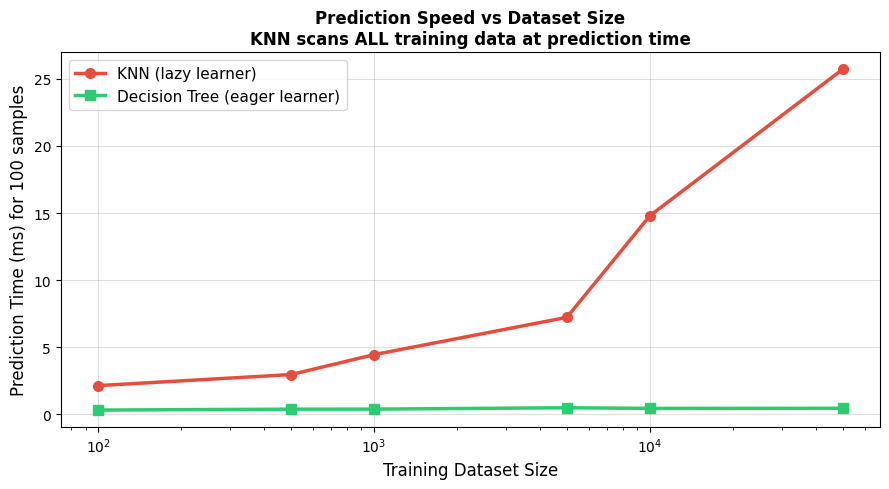

KNN Time Complexity:
  Training    : O(1)     <- just stores data
  Prediction  : O(n * d) <- scans ALL n points, d dimensions
  Space       : O(n)     <- stores all training data in memory

Decision Tree:
  Training    : O(n * d * log n)
  Prediction  : O(log n) <- follows tree path, much faster


In [ ]:
# CELL 19: KNN vs DT — Prediction Time as Dataset Grows

sizes    = [100, 500, 1000, 5000, 10000, 50000]
knn_times = []
dt_times  = []

for n in sizes:
    X_s, y_s = make_classification(n_samples=n, n_features=10, random_state=42)

    k = KNeighborsClassifier(n_neighbors=5)
    k.fit(X_s, y_s)
    t = time.time()
    k.predict(X_s[:100])
    knn_times.append((time.time() - t) * 1000)

    d = DecisionTreeClassifier(random_state=42)
    d.fit(X_s, y_s)
    t = time.time()
    d.predict(X_s[:100])
    dt_times.append((time.time() - t) * 1000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, knn_times, 'o-', color='#E74C3C', linewidth=2.5, markersize=7,
        label='KNN (lazy learner)')
ax.plot(sizes, dt_times, 's-', color='#2ECC71', linewidth=2.5, markersize=7,
        label='Decision Tree (eager learner)')

ax.set_xlabel('Training Dataset Size', fontsize=12)
ax.set_ylabel('Prediction Time (ms) for 100 samples', fontsize=12)
ax.set_title('Prediction Speed vs Dataset Size\nKNN scans ALL training data at prediction time',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xscale('log')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('KNN Time Complexity:')
print('  Training    : O(1)     <- just stores data')
print('  Prediction  : O(n * d) <- scans ALL n points, d dimensions')
print('  Space       : O(n)     <- stores all training data in memory')
print()
print('Decision Tree:')
print('  Training    : O(n * d * log n)')
print('  Prediction  : O(log n) <- follows tree path, much faster')

---
## 15. KNN vs Decision Tree vs Random Forest

In [ ]:
# CELL 20: Algorithm Comparison on Wine Dataset

models_compare = {
    'KNN (K=best, scaled)': KNeighborsClassifier(n_neighbors=best_k_wine),
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42)
}

results_compare = []
for name, model in models_compare.items():
    Xtr_i = X_trws if 'KNN' in name else X_trw
    Xte_i = X_tews if 'KNN' in name else X_tew

    t0 = time.time()
    model.fit(Xtr_i, y_trw)
    train_ms = (time.time() - t0) * 1000

    t0 = time.time()
    preds_i = model.predict(Xte_i)
    pred_ms = (time.time() - t0) * 1000

    acc_i = accuracy_score(y_tew, preds_i)
    cv_i  = cross_val_score(model, Xtr_i, y_trw, cv=5).mean()
    results_compare.append({
        'Model': name, 'Test Acc': f'{acc_i*100:.2f}%',
        'CV Acc': f'{cv_i*100:.2f}%',
        'Train ms': f'{train_ms:.2f}',
        'Predict ms': f'{pred_ms:.3f}'
    })

df_compare = pd.DataFrame(results_compare)
print('Algorithm Comparison — Wine Dataset')
print('='*75)
print(df_compare.to_string(index=False))

Algorithm Comparison — Wine Dataset
               Model Test Acc CV Acc Train ms Predict ms
KNN (K=best, scaled)   97.78% 97.72%     2.16      3.166
       Decision Tree   95.56% 89.54%     1.94      0.287
       Random Forest  100.00% 96.98%   202.08      8.548


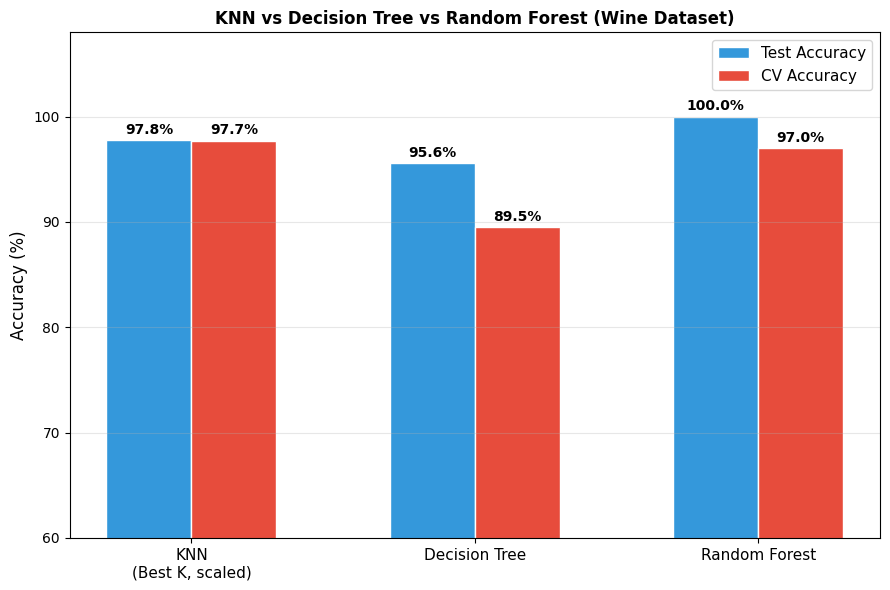

In [ ]:
# CELL 21: Comparison Bar Chart

model_names = ['KNN\n(Best K, scaled)', 'Decision Tree', 'Random Forest']
test_accs   = [float(r['Test Acc'].replace('%','')) for r in results_compare]
cv_accs     = [float(r['CV Acc'].replace('%','')) for r in results_compare]

x = np.arange(len(model_names))
w = 0.3

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - w/2, test_accs, w, label='Test Accuracy', color='#3498DB', edgecolor='white')
b2 = ax.bar(x + w/2, cv_accs,   w, label='CV Accuracy',   color='#E74C3C', edgecolor='white')

for bar in [b1, b2]:
    for rect in bar:
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
                f'{rect.get_height():.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('KNN vs Decision Tree vs Random Forest (Wine Dataset)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(60, 108)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## **16. Assignment Tasks**

Complete all tasks below and submit this notebook with all outputs.

In [ ]:
# ASSIGNMENT TASK 1
# Train KNN with K = 3, 5, 7, 9, 11 on the Iris dataset
# Apply feature scaling
# Compare Train Accuracy and Test Accuracy for each K
# Print a results table and plot a grouped bar chart

k_list = [3, 5, 7, 9, 11]

# Step 1: Use X_iris, y_iris and split with train_test_split
# Step 2: Apply StandardScaler
# Step 3: Loop over k_list, train each KNN, compute train and test accuracy
# Step 4: Store results in a list of dicts -> create a DataFrame
# Step 5: Plot grouped bar chart

# Your code here
print('TASK 1: Complete the code above')

TASK 1: Complete the code above


In [ ]:
# ASSIGNMENT TASK 2
# Apply KNN on the Wine dataset
# Step 1: Without scaling (K=5)
# Step 2: With StandardScaler (K=5)
# Step 3: Find best K using cross-validation (K from 1 to 20)
# Step 4: Train final model with best K
# Step 5: Report accuracy, classification report, confusion matrix


# Your code here
print('TASK 2: Complete the code above')

TASK 2: Complete the code above


In [ ]:
# ASSIGNMENT TASK 3 (Advanced)
# Load any dataset of your choice (Titanic, Students, etc.)
# Apply the complete pipeline:
#   1. Load and explore (shape, dtypes, missing values)
#   2. Handle missing values
#   3. Encode categorical features
#   4. Scale features
#   5. Find best K
#   6. Evaluate and report results
#   7. Compare with Decision Tree


# Hint: You can load Titanic CSV using:
# url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# df = pd.read_csv(url)

# Your code here
print('TASK 3: Complete the code above')

TASK 3: Complete the code above


---
## 17. Summary and Key Takeaways

In [ ]:
# CELL 22: Final Summary


summary = """
====================================================================
        KNN — COMPLETE SUMMARY | NIELIT NDU Ropar
        AI_Faculty: Lovnish Verma | Project Engineer
====================================================================

WHAT IS KNN?
  Non-parametric, lazy learning algorithm.
  No model built during training — memorizes all data.
  Prediction: majority vote of K nearest neighbors.

ALGORITHM STEPS:
  1. Choose K
  2. Compute distance to all training points
  3. Select K nearest points
  4. Majority vote (classification) or average (regression)
  5. Return prediction

CRITICAL RULES:
  * Feature Scaling is MANDATORY (StandardScaler)
  * Small K -> Overfitting | Large K -> Underfitting
  * Find optimal K using Cross-Validation — never guess
  * Use scaler.transform() on new data (NOT fit_transform)

TIME COMPLEXITY:
  Training   : O(1)          Lazy — just stores data
  Prediction : O(n * d)      Scans all n points

ADVANTAGES:
  + Simple to understand
  + No training time
  + Works for classification and regression
  + No assumptions about data distribution

DISADVANTAGES:
  - Slow prediction (grows with dataset)
  - High memory (stores all training data)
  - Sensitive to irrelevant features
  - Poor in high dimensions (curse of dimensionality)

COMPARISON TABLE:
  Feature           KNN              Decision Tree    Random Forest
  ------------      -----------      -------------    -------------
  Learning          Lazy             Eager            Eager
  Train Speed       Fast             Fast             Moderate
  Predict Speed     Slow O(n)        Fast O(log n)    Fast
  Scaling Needed    YES              No               No
  Interpretable     Low              High             Low
  Robust to Noise   Moderate         Low              High

====================================================================
"""
print(summary)


        KNN — COMPLETE SUMMARY | NIELIT NDU Ropar
        AI_Faculty: Lovnish Verma | Project Engineer

WHAT IS KNN?
  Non-parametric, lazy learning algorithm.
  No model built during training — memorizes all data.
  Prediction: majority vote of K nearest neighbors.

ALGORITHM STEPS:
  1. Choose K
  2. Compute distance to all training points
  3. Select K nearest points
  4. Majority vote (classification) or average (regression)
  5. Return prediction

CRITICAL RULES:
  * Feature Scaling is MANDATORY (StandardScaler)
  * Small K -> Overfitting | Large K -> Underfitting
  * Find optimal K using Cross-Validation — never guess
  * Use scaler.transform() on new data (NOT fit_transform)

TIME COMPLEXITY:
  Training   : O(1)          Lazy — just stores data
  Prediction : O(n * d)      Scans all n points

ADVANTAGES:
  + Simple to understand
  + No training time
  + Works for classification and regression
  + No assumptions about data distribution

DISADVANTAGES:
  - Slow prediction (grows 

**Resources:**

* **Medium Blog:** https://medium.com/@sayedebad.777/mastering-k-nearest-neighbors-knn-aa4b2ffca68b **Code_used_in_blog:** https://github.com/ES7/ML-Algorithms/blob/main/3.%20KNN.ipynb

* https://kevinzakka.github.io/2016/07/13/k-nearest-neighbor/ **Tip:** Read Comments .. some libraries are deprecated.

* https://www.geeksforgeeks.org/machine-learning/how-to-find-the-optimal-value-of-k-in-knn/

* https://www.ibm.com/think/topics/knn

* https://ashutoshtripathi.com/2019/08/05/a-complete-guide-to-k-nearest-neighbors-algorithm-knn-using-python/

**Next Chapter:** https://colab.research.google.com/drive/11DMe7Ys0JOy5djSw-ITACRiwgHSzwSyI?usp=sharing